# Python - PY4
## Modulo 2: Machine Learning Avanzado y Feature Engineering
### Notebook 3 de 3 - Modelo de Caja Negra (Random Forest), Comparacion y Reporte Ejecutivo

**Objetivos de este notebook:**
- Entrenar un modelo de ensamble (Random Forest) para maximizar el rendimiento.
- Comparar formalmente los tres modelos que entrenamos en el modulo: Regresion Logistica, Arbol de Decision y Random Forest.
- Analizar la importancia de variables del Random Forest.
- Traducir la Matriz de Confusion en impacto economico para el negocio.
- Redactar el reporte ejecutivo para el Director de Marketing.

**Recordatorio:** este notebook continua el trabajo de los Notebooks 1 y 2. Necesitas los archivos `datos_procesados.pkl`, `resultados_logistico.pkl` y `resultados_arbol.pkl` en la misma carpeta que este notebook.


## 1. Recuperando los datos y resultados anteriores

Cargamos las librerias, los datos que preparamos en el Notebook 1, y los resultados de los modelos que entrenamos en el Notebook 2 (Regresion Logistica y Arbol de Decision).


In [87]:
# Manejo de datos
import pandas as pd
import numpy as np
import pickle

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline

# config visualisacion
sns.set_style("white")
plt.rcParams["figure.figsize"] = (8, 5)


In [75]:
# Datos preparados en el Notebook 1
with open("datos_procesados.pkl", "rb") as f:
    X, X_train, X_test, y_train, y_test = pickle.load(f)

print("Tamanio de entrenamiento:", X_train.shape)
print("Tamanio de prueba:", X_test.shape)


Tamanio de entrenamiento: (9864, 26)
Tamanio de prueba: (2466, 26)


In [77]:
# Resultados de los modelos entrenados en el Notebook 2
with open("resultados_logistico.pkl", "rb") as f:
    resultados_log = pickle.load(f)

with open("resultados_arbol.pkl", "rb") as f:
    resultados_arbol = pickle.load(f)

print("Metricas cargadas para: Regresion Logistica y Arbol de Decision")


{'accuracy': 0.8811841038118411,
 'precision': 0.7431693989071039,
 'recall': 0.35602094240837695,
 'f1': 0.4814159292035398,
 'matriz_confusion': array([[2037,   47],
        [ 246,  136]]),
 'coeficientes':                          variable  coeficiente
 8                      PageValues     1.536608
 21                      Month_Nov     0.178667
 4                  ProductRelated     0.093474
 5         ProductRelated_Duration     0.079986
 11                        Browser     0.064547
 14                        Weekend     0.058456
 2                   Informational     0.053617
 13                    TrafficType     0.028951
 1         Administrative_Duration     0.011985
 23                      Month_Sep     0.006564
 0                  Administrative     0.003944
 3          Informational_Duration    -0.001978
 22                      Month_Oct    -0.008102
 17                      Month_Jul    -0.020336
 12                         Region    -0.027295
 24              Visitor

## 2. Entrenando el modelo de ensamble: Random Forest

Random Forest combina cientos de arboles de decision, cada uno entrenado con una muestra distinta de datos y de variables. Esto se logra con dos trucos de aleatoriedad:

- **Bagging (Bootstrap Aggregating):** cada arbol se entrena con una muestra aleatoria de los datos (i.e. una muestra aleatoria de observaciones).
- **Feature Randomness:** en cada division del arbol, solo se considera un subconjunto aleatorio de variables (i.e. una muestra aleatoria de columnas).

El resultado es un modelo mas robusto y preciso que un solo Arbol de Decision, pero mas dificil de interpretar: por eso se le llama "caja negra".

Al igual que el Arbol de Decision del Notebook 2, Random Forest *no* necesita variables escaladas, asi que usamos `X_train` y `X_test` directamente.


In [55]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,   # cantidad de arboles en el bosque
    random_state=42     # fija la semilla aleatoria para obtener resultados reproducibles
)

modelo_rf.fit(X_train, y_train) # entrenamoc el modelo


RandomForestClassifier(n_estimators=200, random_state=42)

El modelo se entrena con solo esa simple línea de código de arriba, pero pasan muchas cosas por detrás. Vamos a explorar un poco los trees que se han entrenado

In [56]:
# Veamos el suconjunto de features que se han seleccionado aleatoriamente en los primeros árboles.
modelo_rf.estimators_[0].tree_.feature # acceder los indices de los features

for i in range(3):
    arbol = modelo_rf.estimators_[i]

    feature_idx = arbol.tree_.feature # índices de variables utilizadas en los nodos
    feature_idx = feature_idx[feature_idx >= 0] # elimina los nodos hoja (-2)
    variables_usadas = X.columns[feature_idx].unique() # convierte índices a nombres de variables

    print(f"\nÁrbol {i+1}:")
    print(list(variables_usadas))



Árbol 1:
['ProductRelated_Duration', 'BounceRates', 'Administrative', 'PageValues', 'ProductRelated', 'Region', 'ExitRates', 'Browser', 'Month_May', 'TrafficType', 'Weekend', 'Month_Nov', 'OperatingSystems', 'SpecialDay', 'Month_Dec', 'Month_Sep', 'Administrative_Duration', 'VisitorType_Other', 'Informational_Duration', 'VisitorType_Returning_Visitor', 'Month_Mar', 'Month_Oct', 'Informational', 'Month_June', 'Month_Jul', 'Month_Feb']

Árbol 2:
['PageValues', 'Month_May', 'ProductRelated', 'ExitRates', 'ProductRelated_Duration', 'Month_Nov', 'Month_Oct', 'Administrative_Duration', 'Month_Jul', 'Month_Mar', 'Administrative', 'Month_Dec', 'Weekend', 'VisitorType_Returning_Visitor', 'Browser', 'TrafficType', 'BounceRates', 'Month_June', 'Region', 'Informational_Duration', 'Informational', 'OperatingSystems', 'Month_Sep', 'VisitorType_Other', 'Month_Feb', 'SpecialDay']

Árbol 3:
['ProductRelated_Duration', 'BounceRates', 'Month_Oct', 'Month_May', 'ProductRelated', 'Region', 'VisitorType_Re

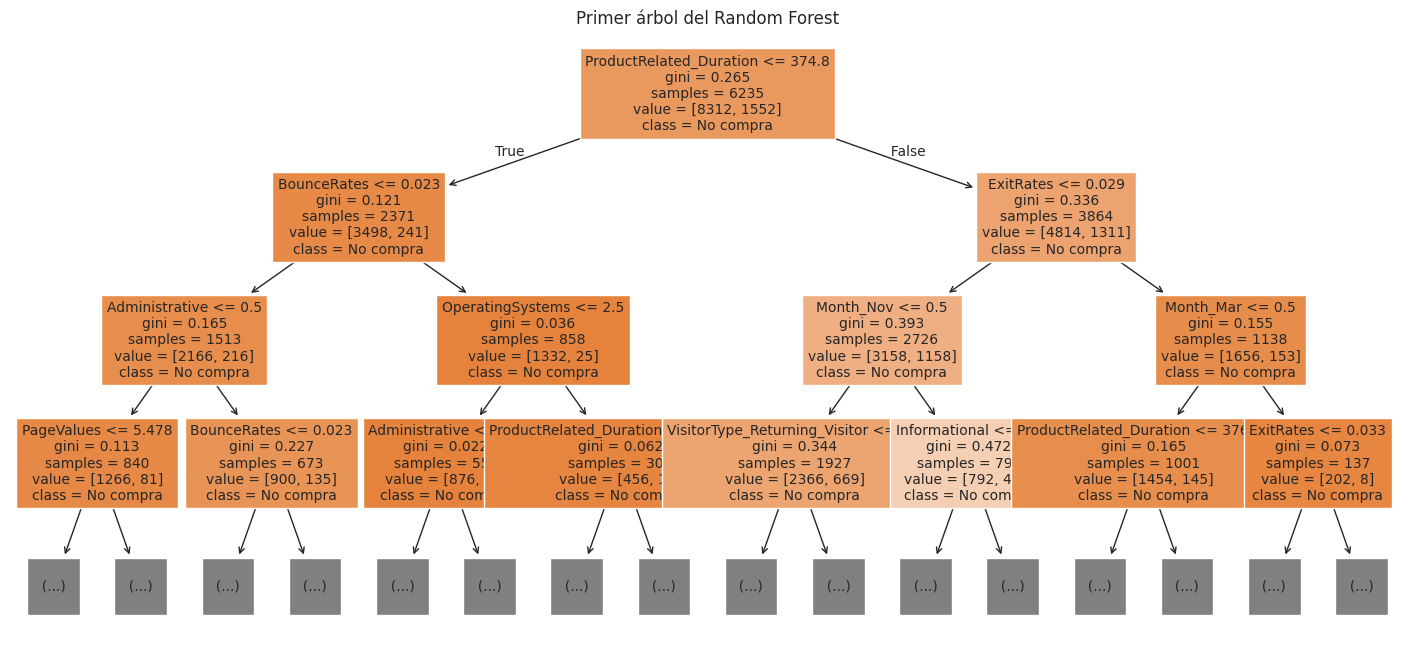

In [57]:
# Nuestro modelo usa 200 arboles, cada arboles hecho de subsample de features y observaciones
# hacemos un plot del primero arbol

from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))

plot_tree(
    modelo_rf.estimators_[0],
    feature_names=X.columns,
    class_names=["No compra", "Compra"],
    filled=True,
    max_depth=3,
    fontsize=10
)

plt.title("Primer árbol del Random Forest")
plt.show()

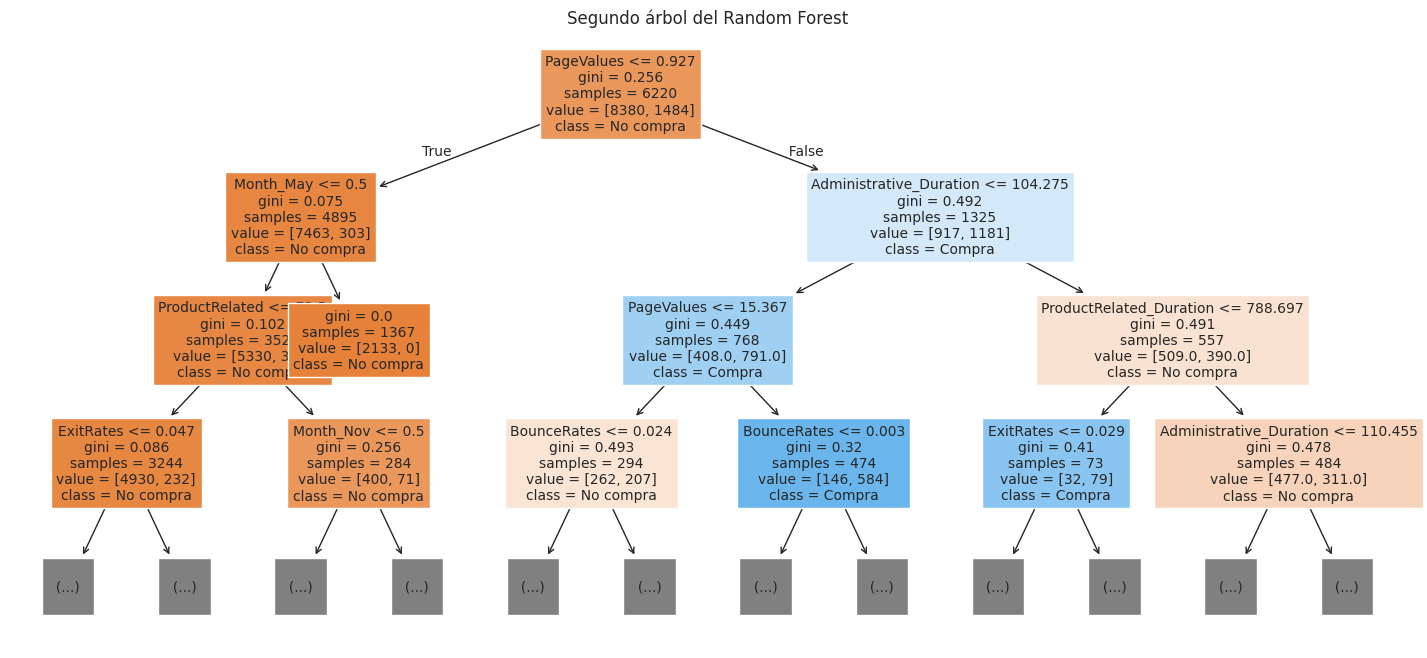

In [58]:
# plot del segundo arbol
plt.figure(figsize=(18, 8))

plot_tree(
    modelo_rf.estimators_[1],
    feature_names=X.columns,
    class_names=["No compra", "Compra"],
    filled=True,
    max_depth=3,
    fontsize=10
)

plt.title("Segundo árbol del Random Forest")
plt.show()

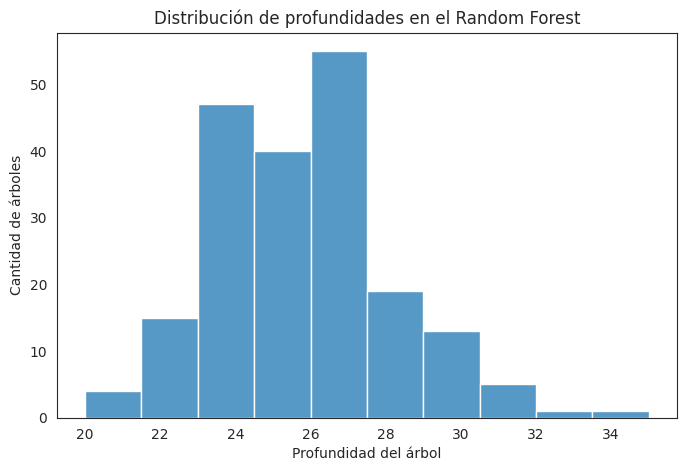

In [59]:
## Chekeamos la variabilidad de depth en los arboles de nuestro modelo
modelo_rf.estimators_[0].get_depth() # profundidad del primero arbol

profundidades = [arbol.get_depth() for arbol in modelo_rf.estimators_]

sns.histplot(profundidades, bins=10)
plt.xlabel("Profundidad del árbol")
plt.ylabel("Cantidad de árboles")
plt.title("Distribución de profundidades en el Random Forest")
plt.show()

## 3. Evaluando el Random Forest

Repetimos el mismo proceso de evaluacion que usamos para los otros dos modelos, para poder comparar de forma justa.


In [60]:
# genera las predicciones del Random Forest sobre el test set
y_pred_rf = modelo_rf.predict(X_test)

# calcula métricas para evaluar el desempeño del modelo
# accuracy: porcentaje total de predicciones correctas
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# precision: proporción de predicciones positivas que fueron correctas
precision_rf = precision_score(y_test, y_pred_rf)

# recall: proporción de casos positivos reales que fueron identificados correctamente
recall_rf = recall_score(y_test, y_pred_rf)

# F1-score: media armónica entre precision y recall
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")

print("\nReporte completo de clasificacion:")
print(classification_report(y_test, y_pred_rf, target_names=["No compra", "Compra"]))


Accuracy:  0.8990
Precision: 0.7333
Recall:    0.5471
F1-score:  0.6267

Reporte completo de clasificacion:
              precision    recall  f1-score   support

   No compra       0.92      0.96      0.94      2084
      Compra       0.73      0.55      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.78      2466
weighted avg       0.89      0.90      0.89      2466



El Accuracy mide el porcentaje total de predicciones correctas sobre todas las observaciones.

El reporte de clasificación calcula Precision, Recall y F1-score para cada clase por separado ("No compra" y "Compra"), permitiendo analizar qué tan bien identifica el modelo cada categoría. Además, incluye promedios (macro y weighted) para resumir el desempeño general del modelo.

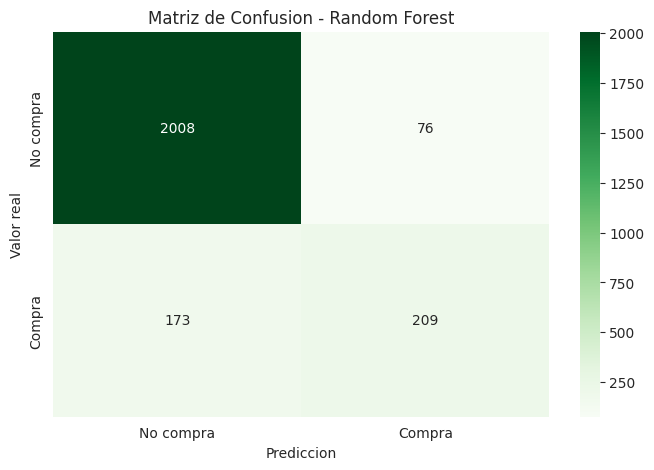

In [61]:
matriz_rf = confusion_matrix(y_test, y_pred_rf) # matriz de confusión comparando las clases reales con las predicciones del Random Forest

sns.heatmap(matriz_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No compra", "Compra"],
            yticklabels=["No compra", "Compra"])
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.title("Matriz de Confusion - Random Forest")
plt.show()


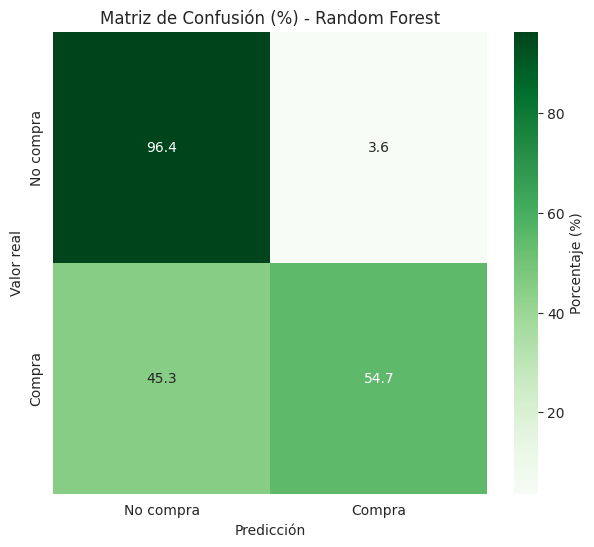

In [62]:
# plot un matriz de confusion pero con los percentage

# porcentaje por clase real (cada fila suma 100%)
matriz_pct = matriz_rf.astype("float") / matriz_rf.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_pct,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    xticklabels=["No compra", "Compra"],
    yticklabels=["No compra", "Compra"],
    cbar_kws={"label": "Porcentaje (%)"}
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión (%) - Random Forest")

plt.show()

El modelo Random Forest muestra un buen desempeño general, con un accuracy de 89.9%. Identifica correctamente la mayoría de los clientes que no compran y logra una precisión aceptable para la clase "Compra". Sin embargo, su recall indica que aún deja sin detectar una parte de los compradores reales.

## 4. Duelo de modelos: comparacion final

Ya entrenaste tres modelos a lo largo del modulo: Regresion Logistica y Arbol de Decision (Notebook 2), y Random Forest (este notebook). Ahora construimos una tabla comparativa con las metricas de los tres. Esta tabla es la base de la recomendacion que le vamos a dar al Director de Marketing.


In [63]:
comparacion = pd.DataFrame({
    "Modelo": ["Regresion Logistica", "Arbol de Decision", "Random Forest"],
    "Accuracy": [resultados_log["accuracy"], resultados_arbol["accuracy"], accuracy_rf],
    "Precision": [resultados_log["precision"], resultados_arbol["precision"], precision_rf],
    "Recall": [resultados_log["recall"], resultados_arbol["recall"], recall_rf],
    "F1-score": [resultados_log["f1"], resultados_arbol["f1"], f1_rf],
})

comparacion


,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresion Logistica,0.881184,0.743169,0.356021,0.481416
1,Arbol de Decision,0.896188,0.773913,0.465969,0.581699
2,Random Forest,0.899027,0.733333,0.547120,0.626687


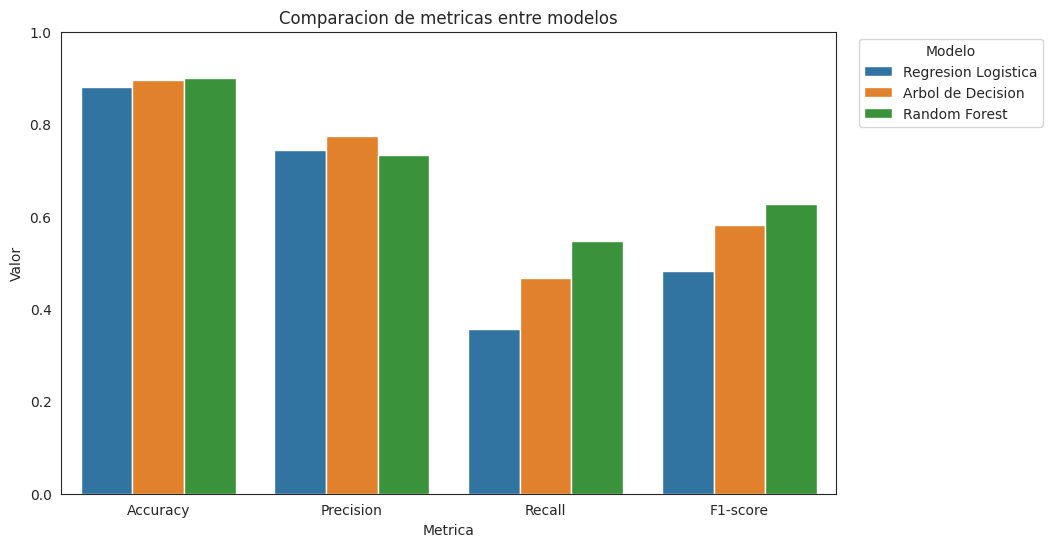

In [64]:
# Visualizamos la comparacion de metricas entre los tres modelos
comparacion_larga = comparacion.melt(id_vars="Modelo", var_name="Metrica", value_name="Valor") # melt() transforma un DataFrame de formato ancho (wide) a formato largo (long)

plt.figure(figsize=(10, 6))
sns.barplot(data=comparacion_larga, x="Metrica", y="Valor", hue="Modelo")
plt.title("Comparacion de metricas entre modelos")
plt.ylim(0, 1)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


**Como leer esta comparacion:** no existe un modelo "ganador absoluto", existe el modelo mas adecuado segun lo que el negocio necesita. Un Accuracy un poco mas alto no sirve de mucho si el Recall es bajo y estamos perdiendo muchas ventas. Ten esto en mente para el reporte ejecutivo.


## 5. Importancia de variables en el Random Forest

El Random Forest no tiene coeficientes como la Regresion Logistica, pero si nos puede decir que tan importante fue cada variable para tomar las decisiones dentro de los arboles.


In [65]:
modelo_rf.feature_importances_

importancias_rf = pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo_rf.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancias_rf.head(10)


,variable,importancia
8,PageValues,0.365884
7,ExitRates,0.091978
5,ProductRelated_Duration,0.089247
4,ProductRelated,0.071022
1,Administrative_Duration,0.058222
6,BounceRates,0.056087
0,Administrative,0.042522
13,TrafficType,0.031882
12,Region,0.031162
3,Informational_Duration,0.026272


/tmp/ipykernel_11135/3160195477.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_rf.head(10), x="importancia", y="variable", palette="viridis")


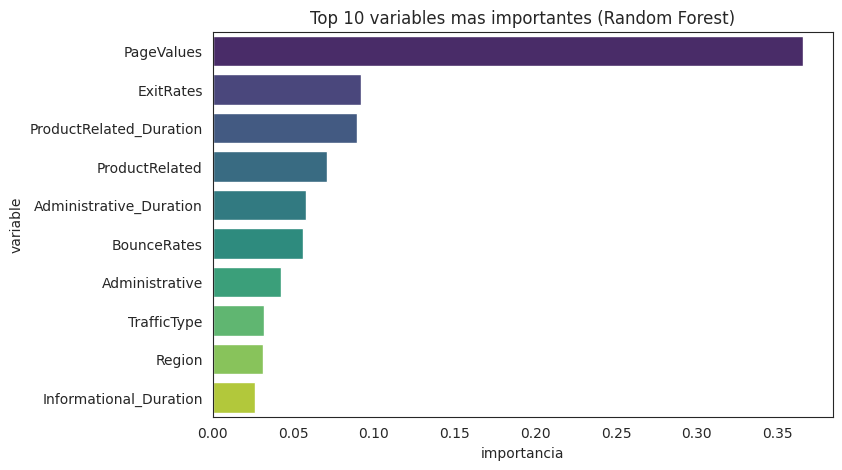

In [66]:
sns.barplot(data=importancias_rf.head(10), x="importancia", y="variable", palette="viridis")
plt.title("Top 10 variables mas importantes (Random Forest)")
plt.show()


## Interpretación del modelo con Partial Dependence Plots (PDP)

Aunque la importancia de variables (`feature_importances_`) permite identificar cuáles son las variables más relevantes para el Random Forest, no indica **cómo** afectan la predicción.

Los **Partial Dependence Plots (PDP)** muestran cómo cambia la probabilidad promedio de compra cuando una variable varía, manteniendo el resto de las variables con sus valores observados en el conjunto de datos.

Esto permite comprender la relación entre una variable y la predicción del modelo.

<Figure size 700x500 with 0 Axes>

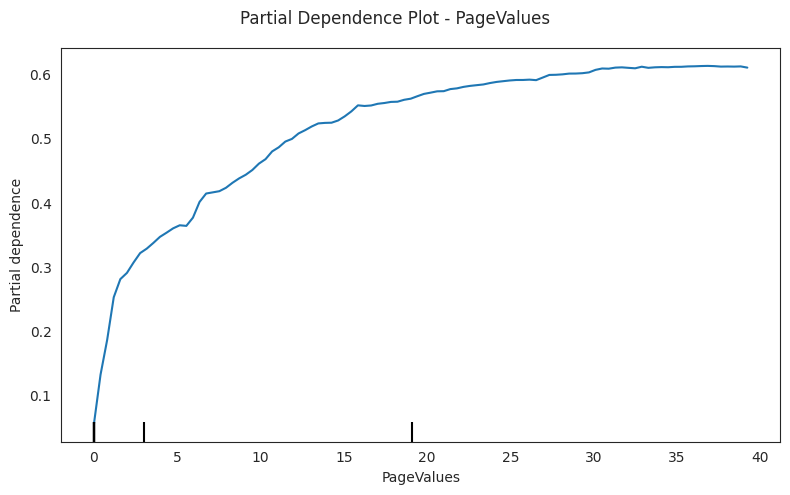

In [67]:
from sklearn.inspection import PartialDependenceDisplay

# investiguemos la influencia de PageValues

plt.figure(figsize=(7,5))

PartialDependenceDisplay.from_estimator(
    modelo_rf,
    X_train,
    features=["PageValues"],
    kind="average"
)

plt.suptitle("Partial Dependence Plot - PageValues")
plt.tight_layout()
plt.show()

### Interpretación

- El eje **X** representa los valores de la variable.
- El eje **Y** representa la predicción promedio del modelo.

Si la curva aumenta, significa que valores más altos de la variable incrementan la probabilidad de compra. Si disminuye, ocurre lo contrario.  


¿Qué variables son importantes? → feature_importances

¿Cómo afectan la predicción? → Partial Dependency Plot

## 6. Descubriendo el Boosting con XGBoost

Random Forest construye sus arboles en paralelo, cada uno de forma independiente (esto se llama **Bagging**). Existe otra gran familia de modelos de ensamble que construye los arboles de forma secuencial, donde cada arbol nuevo intenta corregir los errores del arbol anterior: esto se llama **Boosting**.

**XGBoost** (Extreme Gradient Boosting) es una de las implementaciones de boosting mas usadas en la industria: es muy comun en competencias de Machine Learning (Kaggle) y en produccion, por su buen balance entre velocidad y rendimiento.

No vamos a profundizar en el detalle matematico de boosting en este modulo, pero vale la pena que lo conozcas, lo entrenes, y aproveches para dar tus primeros pasos con **Hyperparameter Tuning** (el proceso de buscar los mejores parametros para un modelo).


### 6.1 Entrenando un XGBoost basico (parametros por defecto)

Igual que el Random Forest, XGBoost no necesita variables escaladas. Primero lo entrenamos con los parametros por defecto, sin ajustar nada todavia. Este va a ser nuestro punto de partida para comparar mas adelante.


In [68]:
# Si XGBoost no esta instalado en tu entorno, descomenta la siguiente linea
# !pip install xgboost

from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    random_state=42,        # fija la semilla aleatoria para obtener resultados reproducibles
    eval_metric="logloss"   # metrica interna que usa XGBoost durante el entrenamiento
)

modelo_xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Evaluando el XGBoost basico

Repetimos el mismo proceso de evaluacion que usamos con los otros modelos.


In [69]:
y_pred_xgb = modelo_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-score:  {f1_xgb:.4f}")


Accuracy:  0.8925
Precision: 0.6834
Recall:    0.5707
F1-score:  0.6220


### 6.2 Ajustando los hiperparametros (Hyperparameter Tuning)

Hasta ahora entrenamos todos los modelos del modulo con sus parametros por defecto (o con ajustes muy simples, como el `max_depth` del Arbol de Decision). En la practica, despues de elegir un modelo, el siguiente paso es buscar la **mejor combinacion de parametros** para esa tarea especifica. Esto se llama **Hyperparameter Tuning**, y es basicamente lo que hace que un modelo pase de "bueno" a "el mejor posible" para tu problema.

Algunos de los hiperparametros mas importantes en XGBoost:

- **n_estimators:** cuantos arboles se construyen en total.
- **max_depth:** que tan profundo puede llegar a ser cada arbol.
- **learning_rate:** que tan grande es el ajuste que hace cada arbol nuevo sobre los errores del arbol anterior. Valores mas chicos significan un aprendizaje mas lento pero mas estable (usualmente se compensa usando mas arboles).

En vez de probar combinaciones a mano, usamos `GridSearchCV`: le damos una lista de valores posibles para cada parametro, y prueba automaticamente todas las combinaciones posibles, usando validacion cruzada (cross-validation) para evaluar cada una de forma confiable.


In [70]:
from sklearn.model_selection import GridSearchCV

# Definimos una grilla pequenia de parametros para no demorar demasiado en clase
grilla_parametros = {
    "n_estimators": [100, 200],     # cantidad de árboles del modelo
    "max_depth": [3, 5],            # profundidad máxima de cada árbol
    "learning_rate": [0.05, 0.1],   # velocidad con la que el modelo aprende
}

# configura una búsqueda exhaustiva para encontrar la mejor combinación de hiperparámetros
busqueda = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="logloss"),  # modelo base
    param_grid=grilla_parametros,   # combinaciones de parámetros a evaluar
    scoring="recall",               # optimiza Recall para detectar la mayor cantidad posible de compradores
    cv=3,                           # evalúa cada combinación mediante validación cruzada de 3 particiones
    n_jobs=-1                       # utiliza todos los núcleos disponibles del procesador
)

busqueda.fit(X_train, y_train)

print("Mejores parametros encontrados:", busqueda.best_params_)


Mejores parametros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


### Entrenando el XGBoost con los mejores parametros

`GridSearchCV` ya entrena automaticamente un modelo final usando los mejores parametros que encontro (disponible en `busqueda.best_estimator_`). Lo evaluamos igual que hicimos con el modelo basico, para poder comparar el antes y el despues del tuning.


In [71]:
modelo_xgb_tuned = busqueda.best_estimator_

y_pred_xgb_tuned = modelo_xgb_tuned.predict(X_test)

accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)

print(f"Accuracy:  {accuracy_xgb_tuned:.4f}")
print(f"Precision: {precision_xgb_tuned:.4f}")
print(f"Recall:    {recall_xgb_tuned:.4f}")
print(f"F1-score:  {f1_xgb_tuned:.4f}")


Accuracy:  0.9002
Precision: 0.7222
Recall:    0.5785
F1-score:  0.6424


### 6.3 XGBoost antes y despues del tuning

Comparemos los cuatro numeros del modelo basico contra los del modelo ajustado.


In [72]:
comparacion_xgb = pd.DataFrame({
    "Version": ["XGBoost basico (parametros por defecto)", "XGBoost ajustado (GridSearchCV)"],
    "Accuracy": [accuracy_xgb, accuracy_xgb_tuned],
    "Precision": [precision_xgb, precision_xgb_tuned],
    "Recall": [recall_xgb, recall_xgb_tuned],
    "F1-score": [f1_xgb, f1_xgb_tuned],
})

comparacion_xgb


,Version,Accuracy,Precision,Recall,F1-score
0,XGBoost basico (parametros por defecto),0.892539,0.683386,0.570681,0.621969
1,XGBoost ajustado (GridSearchCV),0.900243,0.722222,0.578534,0.642442


Puede que la mejora entre el modelo basico y el ajustado sea pequenia, o incluso que un parametro puntual no cambie mucho el resultado: eso tambien es un aprendizaje valido. El tuning no siempre produce saltos enormes, pero es la diferencia entre un modelo "que funciona" y un modelo verdaderamente optimizado para tu problema. En proyectos reales se prueban grillas de parametros mucho mas grandes (y tecnicas mas avanzadas como `RandomizedSearchCV` o `Optuna`), pero la logica de fondo es la misma que acabas de aplicar aqui.

Quedate con las dos ideas clave de esta seccion:

1. **Bagging (Random Forest)** y **Boosting (XGBoost)** son las dos grandes familias de modelos de ensamble basados en arboles. Ambas construyen muchos arboles, pero de forma distinta: en paralelo e independiente (bagging) o de forma secuencial, corrigiendo errores (boosting).
2. **Hyperparameter Tuning** es el proceso de buscar la mejor configuracion de un modelo ya elegido. Es un paso que vas a repetir con casi cualquier modelo que entrenes en el futuro.


## Modelos Ensemble y Voting Classifier

Un **modelo ensemble** combina varios modelos de Machine Learning para obtener una predicción más robusta que la de un modelo individual.

La idea principal es que diferentes modelos pueden cometer errores distintos. Al combinar sus predicciones, el ensemble puede reducir errores y mejorar el desempeño general.

El **Voting Classifier** es un tipo de ensemble que entrena varios modelos y combina sus resultados mediante votación:

- En **hard voting**, cada modelo vota por una clase y se elige la clase con más votos.
- En **soft voting**, se promedian las probabilidades predichas por cada modelo y se selecciona la clase con mayor probabilidad.

En este caso combinamos modelos con comportamientos diferentes:
- Regresión Logística: modelo lineal y simple.
- Árbol de decisión: captura reglas no lineales.
- Random Forest: combina muchos árboles para reducir la varianza.
- XGBoost: utiliza boosting para mejorar iterativamente las predicciones.

La combinación busca aprovechar las fortalezas de cada modelo individual.

In [107]:

## entrena de nuevo el modelo logistico y simple arbol de decision (como en el notebook anterior)
modelo_logistico = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])
modelo_logistico.fit(X_train, y_train)

## entrena de nuevo el simple decision tree
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arbol.fit(X_train, y_train)


## creamos un ensemble modelo "VotingClassifier"
voting_clf = VotingClassifier(
    estimators=[
        ("logistico", modelo_logistico),
        ("arbol", modelo_arbol),
        ("random_forest", modelo_rf),
        ("xgboost", modelo_xgb_tuned)])

voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('logistico',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('logreg',
                                               LogisticRegression(max_iter=1000,
                                                                  random_state=42))])),
                             ('arbol',
                              DecisionTreeClassifier(max_depth=4,
                                                     random_state=42)),
                             ('random_forest',
                              RandomForestClassifier(n_estimators=200,
                                                     random_state=42)),
                             ('xgboost',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...))])

In [114]:
# check el accuracy de cada modelo
for name, clf in voting_clf.named_estimators_.items():
    print(f"{name} = {clf.score(X_test, y_test):.4f}")

# check el accuracy del voting classifier
voting_clf.voting = "soft"

print()
print(f"Overall accuracy del Voting: {voting_clf.score(X_test, y_test):.2f}")

logistico = 0.8812
arbol = 0.8962
random_forest = 0.8990
xgboost = 0.9002

Overall accuracy del Voting: 0.91


## 7. Reporte Ejecutivo para el Director de Marketing

Ahora que tienes toda la evidencia (metricas, matrices de confusion, importancia de variables, impacto economico), completa el siguiente reporte. Este es el entregable mas importante del modulo: debe estar escrito en lenguaje de negocio, sin jerga tecnica innecesaria.

Podemos responder:

1. Que modelo recomiendas para produccion y por que?
2. Que variable influye mas en la compra segun el modelo explicable (Regresion Logistica o Arbol de Decision)?
3. Que accion concreta le sugerirías al equipo de Marketing con base en esta variable?


## Cierre del Modulo

Con esto terminas el benchmarking de algoritmos de Regresion vs Clasificacion. Resumen de lo que hiciste en los 3 notebooks:

- **Notebook 1:** preparaste un dataset real de e-commerce con exploracion de datos y Feature Engineering.
- **Notebook 2:** entrenaste dos modelos interpretables (Regresion Logistica y Arbol de Decision), entendiendo Precision y Recall.
- **Notebook 3:** entrenaste un modelo de ensamble (Random Forest), comparaste los tres modelos y escribiste una recomendacion de negocio.
